In [1]:
import pandas as pd
import numpy as np
from functools import reduce
import seaborn as sns
import yaml
import matplotlib.pyplot as plt

In [2]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

In [3]:
# importing all the necessary clean data
df_cc = pd.read_csv(config['data']['clean']['file1'], quotechar='"', sep = ";")
df_hu = pd.read_csv(config['data']['clean']['file2'], quotechar='"', sep = ";")
df_pp = pd.read_csv(config['data']['clean']['file3'], quotechar='"', sep = ";")
df_qq = pd.read_csv(config['data']['clean']['file4'], quotechar='"', sep = ";")
df_rr = pd.read_csv(config['data']['clean']['file5'], quotechar='"', sep = ";")
df_sd = pd.read_csv(config['data']['clean']['file6'], quotechar='"', sep = ";")
df_ss = pd.read_csv(config['data']['clean']['file7'], quotechar='"', sep = ";")
df_tg = pd.read_csv(config['data']['clean']['file8'], quotechar='"', sep = ";")
df_tn = pd.read_csv(config['data']['clean']['file9'], quotechar='"', sep = ";")
df_tx = pd.read_csv(config['data']['clean']['file10'], quotechar='"', sep = ";")
df_heatwave = pd.read_csv(config['data']['clean']['file11'], quotechar='"', sep = ";")

In [4]:
# merging all data to one dataframe: all_data
all_data = reduce(lambda  left,right: pd.merge(left,right,on=['date'],how='outer'), [df_cc,df_hu,df_pp, df_qq,df_rr,df_sd,df_ss,df_tg,df_tn, df_tx])
all_data.date  = pd.to_datetime(all_data.date, format='%Y-%m-%d')

In [5]:
all_data = all_data.drop(all_data[(all_data["date"].dt.month == 2) &(all_data["date"].dt.day == 29)].index)

In [6]:
heatwave_cols = df_heatwave.drop(columns=["tx", "tn"],errors="ignore")

In [7]:
heatwave_cols["date"] = pd.to_datetime(heatwave_cols["date"])

In [8]:
all_data = pd.merge(all_data,heatwave_cols,on="date",how="left")

In [9]:
all_data.isna().sum()

date                     0
cc                       0
hu                       0
pp                       0
qq                       0
rr                       0
sd                       0
ss                       0
tg                       0
tn                       0
tx                       0
year                     0
month                    0
day                      0
doy                      0
tx_p90                   0
tn_p90                   0
above_tx_p90             0
above_tn_p90             0
above_baseline_day       0
heatwave                 0
heatwave_start           0
heatwave_summer          0
heatwave_start_summer    0
dtype: int64

In [10]:
all_data.shape

(17155, 24)

In [11]:
all_data.columns

Index(['date', 'cc', 'hu', 'pp', 'qq', 'rr', 'sd', 'ss', 'tg', 'tn', 'tx',
       'year', 'month', 'day', 'doy', 'tx_p90', 'tn_p90', 'above_tx_p90',
       'above_tn_p90', 'above_baseline_day', 'heatwave', 'heatwave_start',
       'heatwave_summer', 'heatwave_start_summer'],
      dtype='str')

In [12]:
all_data.year.min()

np.int64(1979)

In [13]:
all_data.year.max()

np.int64(2025)

In [14]:
all_data.head()

,date,cc,hu,pp,qq,rr,sd,ss,tg,tn,...,doy,tx_p90,tn_p90,above_tx_p90,above_tn_p90,above_baseline_day,heatwave,heatwave_start,heatwave_summer,heatwave_start_summer
0,1979-01-01,2.0,83.0,10190.0,52.0,4.0,9.0,70,-4.1,-7.5,...,1,12.41,6.81,False,False,False,False,False,False,False
1,1979-01-02,6.0,76.0,10253.0,27.0,0.0,8.0,17,-2.6,-7.5,...,2,12.50,6.80,False,False,False,False,False,False,False
2,1979-01-03,5.0,86.0,10205.0,13.0,0.0,4.0,0,-2.8,-7.2,...,3,12.51,6.90,False,False,False,False,False,False,False
3,1979-01-04,8.0,68.0,10084.0,13.0,0.0,2.0,0,-2.6,-6.5,...,4,12.60,6.90,False,False,False,False,False,False,False
4,1979-01-05,6.0,73.0,10225.0,29.0,0.0,1.0,20,-0.8,-1.4,...,5,12.50,7.01,False,False,False,False,False,False,False


In [15]:

all_data["doy_sin"] = np.sin(2 * np.pi * all_data["doy"] / 365.25)
all_data["doy_cos"] = np.cos(2 * np.pi * all_data["doy"] / 365.25)
all_data["tx_lag1"] = all_data["tx"].shift(1)
all_data["tx_lag3"] = all_data["tx"].shift(3)
all_data["tx_lag7"] = all_data["tx"].shift(7)

all_data["tn_lag1"] = all_data["tn"].shift(1)
all_data["tg_lag1"] = all_data["tg"].shift(1)

all_data["pp_lag1"] = all_data["pp"].shift(1)
all_data["hu_lag1"] = all_data["hu"].shift(1)
all_data["rr_lag1"] = all_data["rr"].shift(1)
all_data["cc_lag1"] = all_data["cc"].shift(1)


In [16]:
all_data.head()

,date,cc,hu,pp,qq,rr,sd,ss,tg,tn,...,doy_cos,tx_lag1,tx_lag3,tx_lag7,tn_lag1,tg_lag1,pp_lag1,hu_lag1,rr_lag1,cc_lag1
0,1979-01-01,2.0,83.0,10190.0,52.0,4.0,9.0,70,-4.1,-7.5,...,0.999852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1979-01-02,6.0,76.0,10253.0,27.0,0.0,8.0,17,-2.6,-7.5,...,0.999408,2.3,NaN,NaN,-7.5,-4.1,10190.0,83.0,4.0,2.0
2,1979-01-03,5.0,86.0,10205.0,13.0,0.0,4.0,0,-2.8,-7.2,...,0.998669,1.6,NaN,NaN,-7.5,-2.6,10253.0,76.0,0.0,6.0
3,1979-01-04,8.0,68.0,10084.0,13.0,0.0,2.0,0,-2.6,-6.5,...,0.997634,1.3,2.3,NaN,-7.2,-2.8,10205.0,86.0,0.0,5.0
4,1979-01-05,6.0,73.0,10225.0,29.0,0.0,1.0,20,-0.8,-1.4,...,0.996303,-0.3,1.6,NaN,-6.5,-2.6,10084.0,68.0,0.0,8.0


In [17]:
all_data.isna().sum()

date                     0
cc                       0
hu                       0
pp                       0
qq                       0
rr                       0
sd                       0
ss                       0
tg                       0
tn                       0
tx                       0
year                     0
month                    0
day                      0
doy                      0
tx_p90                   0
tn_p90                   0
above_tx_p90             0
above_tn_p90             0
above_baseline_day       0
heatwave                 0
heatwave_start           0
heatwave_summer          0
heatwave_start_summer    0
doy_sin                  0
doy_cos                  0
tx_lag1                  1
tx_lag3                  3
tx_lag7                  7
tn_lag1                  1
tg_lag1                  1
pp_lag1                  1
hu_lag1                  1
rr_lag1                  1
cc_lag1                  1
dtype: int64

**FEATURES ENGINEERING**

In [18]:
df_hw = all_data.drop(columns=[
    'date',
    'above_tx_p90',
    'above_tn_p90',
    'above_baseline_day',
    'heatwave_start',
    'heatwave_summer',
    'heatwave_start_summer',
    'tx_p90',
    'tn_p90',
    'doy'
])

In [19]:
# dropping columns that are too correlated between them: 
df_hw = all_data.drop(columns=['year','month','day','above_tx_p90','above_tn_p90','above_baseline_day','heatwave_start','heatwave_summer','heatwave_start_summer','tx_p90','tn_p90','doy','date','tg','tg_lag1','tx_lag3','tx_lag7','qq','pp','hu','cc','rr','sd'])

In [20]:
#df_hw.to_csv("/Users/iirene/Desktop/heatwave_data.csv", index=False)

In [21]:
df_hw.corr()

,ss,tn,tx,heatwave,doy_sin,doy_cos,tx_lag1,tn_lag1,pp_lag1,hu_lag1,rr_lag1,cc_lag1
ss,1.000000,0.230222,0.473158,0.175556,0.039271,-0.457232,0.496689,0.320572,-0.001756,-0.019407,-0.016310,0.046194
tn,0.230222,1.000000,0.841290,0.148262,-0.362374,-0.729887,0.874227,0.886270,0.012261,0.003436,-0.013761,0.072336
tx,0.473158,0.841290,1.000000,0.260308,-0.269434,-0.812368,0.941227,0.807733,0.013754,-0.008374,-0.019677,0.054998
heatwave,0.175556,0.148262,0.260308,1.000000,0.014172,-0.038218,0.231188,0.116045,0.012749,0.006934,-0.002204,-0.000025
doy_sin,0.039271,-0.362374,-0.269434,0.014172,1.000000,-0.000009,-0.283391,-0.374907,-0.029729,-0.019849,-0.012641,0.028372
doy_cos,-0.457232,-0.729887,-0.812368,-0.038218,-0.000009,1.000000,-0.807586,-0.723505,-0.006297,0.001844,0.046066,-0.086296
tx_lag1,0.496689,0.874227,0.941227,0.231188,-0.283391,-0.807586,1.000000,0.841268,0.015338,-0.004992,-0.018386,0.059915
tn_lag1,0.320572,0.886270,0.807733,0.116045,-0.374907,-0.723505,0.841268,1.000000,0.006798,0.001904,-0.016825,0.085775
pp_lag1,-0.001756,0.012261,0.013754,0.012749,-0.029729,-0.006297,0.015338,0.006798,1.000000,0.687303,-0.004106,0.241415
hu_lag1,-0.019407,0.003436,-0.008374,0.006934,-0.019849,0.001844,-0.004992,0.001904,0.687303,1.000000,0.001465,0.263441


In [22]:
df_hw = df_hw.drop(columns=['pp_lag1', 'hu_lag1', 'rr_lag1', 'cc_lag1'])

In [23]:
df_hw.corr()

,ss,tn,tx,heatwave,doy_sin,doy_cos,tx_lag1,tn_lag1
ss,1.000000,0.230222,0.473158,0.175556,0.039271,-0.457232,0.496689,0.320572
tn,0.230222,1.000000,0.841290,0.148262,-0.362374,-0.729887,0.874227,0.886270
tx,0.473158,0.841290,1.000000,0.260308,-0.269434,-0.812368,0.941227,0.807733
heatwave,0.175556,0.148262,0.260308,1.000000,0.014172,-0.038218,0.231188,0.116045
doy_sin,0.039271,-0.362374,-0.269434,0.014172,1.000000,-0.000009,-0.283391,-0.374907
doy_cos,-0.457232,-0.729887,-0.812368,-0.038218,-0.000009,1.000000,-0.807586,-0.723505
tx_lag1,0.496689,0.874227,0.941227,0.231188,-0.283391,-0.807586,1.000000,0.841268
tn_lag1,0.320572,0.886270,0.807733,0.116045,-0.374907,-0.723505,0.841268,1.000000


# 1. **KNN**

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, ConfusionMatrixDisplay)

In [25]:
df = df_hw

features = ["tx", "tx_lag1", "ss", "tn", "tn_lag1", "doy_sin", "doy_cos"]
target = "heatwave"

model_data = df[features + [target]].dropna()
X = model_data[features]
y = model_data[target].astype(int)

In [27]:
# chronological train/test split: train through 2021, test on 2022 onward

model_data = all_data[features + [target, "year"]].dropna()

train_data = model_data[model_data["year"] <= 2021]
test_data  = model_data[model_data["year"] >= 2022]

X_train = train_data[features]   # "features" list does NOT include "year", so it's correctly excluded here
y_train = train_data[target].astype(int)
X_test  = test_data[features]
y_test  = test_data[target].astype(int)

print(f"Train: {len(X_train)} records ({train_data['year'].min()}–{train_data['year'].max()})")
print(f"Test:  {len(X_test)} records ({test_data['year'].min()}–{test_data['year'].max()})")
print(f"Train heatwave rate: {y_train.mean()*100:.2f}%")
print(f"Test heatwave rate:  {y_test.mean()*100:.2f}%")

Train: 15694 records (1979–2021)
Test:  1460 records (2022–2025)
Train heatwave rate: 4.57%
Test heatwave rate:  10.55%


In [28]:
# Train/test split 
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

# Normalize (fit on train only)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # transform only, not fit_transform

KNN RESULTS
              precision    recall  f1-score   support

 No Heatwave       0.97      0.99      0.98      3257
    Heatwave       0.77      0.45      0.57       174

    accuracy                           0.97      3431
   macro avg       0.87      0.72      0.78      3431
weighted avg       0.96      0.97      0.96      3431



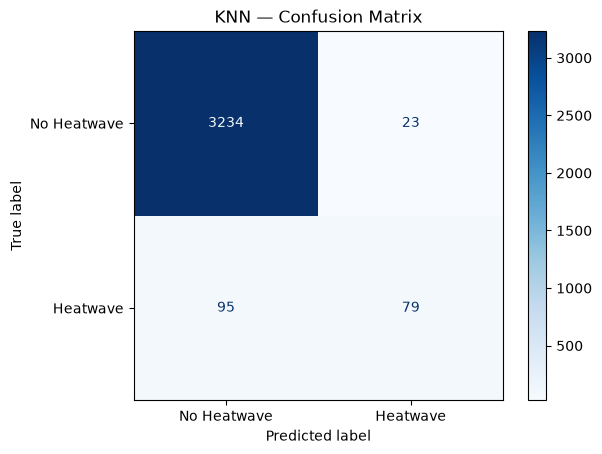

In [29]:
#KNN 
knn = KNeighborsClassifier(n_neighbors=5,metric="euclidean")
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("=" * 50)
print("KNN RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred_knn, target_names=["No Heatwave", "Heatwave"]))

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=["No Heatwave", "Heatwave"]).plot(cmap="Blues")
plt.title("KNN — Confusion Matrix")
plt.show()

In [30]:
pred = knn.predict(X_test)
np.where(pred != y_test.values)

/Users/iirene/Desktop/IRONHACK/Week7/PROJECT/ML-project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


(array([   0,    1,    2, ..., 3427, 3428, 3430], shape=(3147,)),)

In [31]:
print(f"The accuracy the KNN model is {knn.score(X_test_scaled, y_test)*100: .2f}%")

The accuracy the KNN model is  96.56%


# 2. RANDOM FOREST

In [32]:
# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, make_scorer

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [33]:
# create random forest model and fit to our data:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
# level of accuracy of the model:
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"The accuracy of the RandomForest model is {accuracy*100: .2f}%")

The accuracy of the RandomForest model is  97.03%


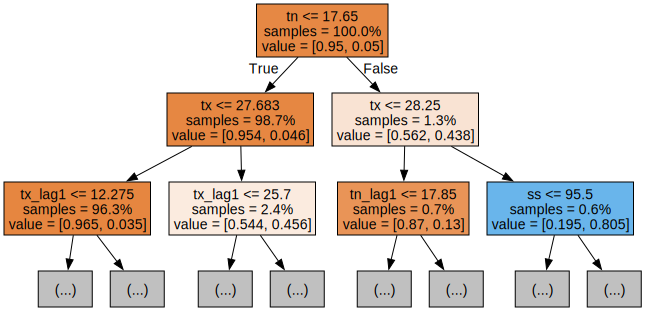

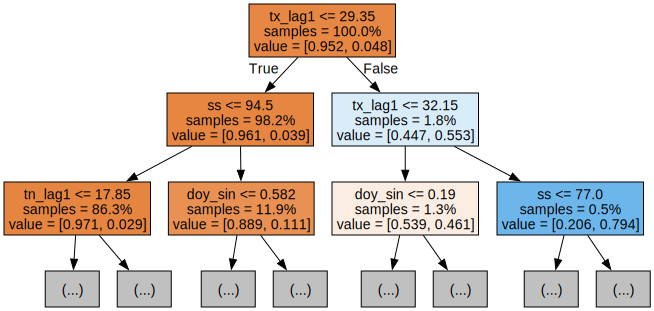

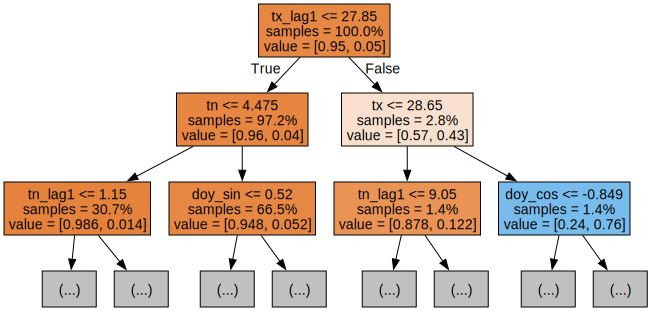

In [35]:
# visualize the first 3 trees: 
for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

 No Heatwave       0.97      0.99      0.98      3257
    Heatwave       0.83      0.52      0.64       174

    accuracy                           0.97      3431
   macro avg       0.90      0.76      0.81      3431
weighted avg       0.97      0.97      0.97      3431



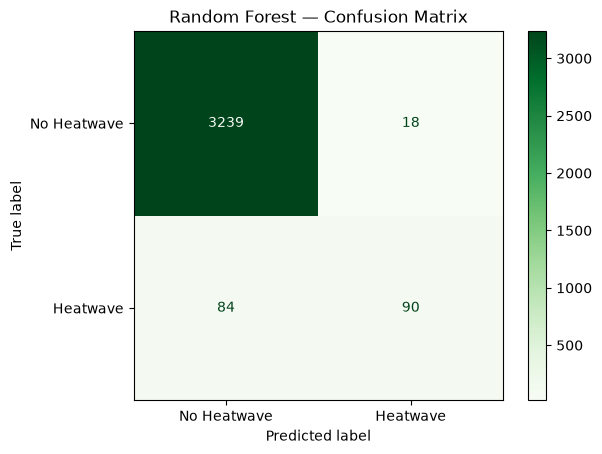

In [36]:
# generate predictions 
y_pred_rf = rf.predict(X_test)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=["No Heatwave", "Heatwave"]))

# create the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=["No Heatwave", "Heatwave"]).plot(cmap="Greens")
plt.title("Random Forest — Confusion Matrix")
plt.show()

In [37]:
# Side-by-side comparison
from sklearn.metrics import f1_score, precision_score, recall_score

comparison = pd.DataFrame({
    "Model": ["KNN", "Random Forest"],
    "Precision (Heatwave)": [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall (Heatwave)": [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 (Heatwave)": [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_rf)
    ]
})

print(comparison.to_string(index=False))

        Model  Precision (Heatwave)  Recall (Heatwave)  F1 (Heatwave)
          KNN              0.774510           0.454023       0.572464
Random Forest              0.833333           0.517241       0.638298


In [38]:
# Random forest was slightly better but the model is still missing 52% of the heatwaves.

# 3. CLASS IMBALANCE

In [39]:
from sklearn.utils import resample

# combine train data temporarily
train_data = X_train.copy()
train_data["heatwave"] = y_train.values

# separate majority and minority classes
majority = train_data[train_data["heatwave"] == 0]
minority = train_data[train_data["heatwave"] == 1]

print(f"Before oversampling: majority={len(majority)}, minority={len(minority)}")

# oversample minority class to match majority
minority_upsampled = resample(
    minority,
    replace=True,               
    n_samples=len(majority),    
    random_state=42)

train_balanced = pd.concat([majority, minority_upsampled])
train_balanced = train_balanced.sample(frac=1, random_state=42)  # shuffle

X_train_balanced = train_balanced.drop(columns=["heatwave"])
y_train_balanced = train_balanced["heatwave"]

print(f"After oversampling: {train_balanced['heatwave'].value_counts().to_dict()}")

Before oversampling: majority=13026, minority=697
After oversampling: {1: 13026, 0: 13026}


In [40]:
# retrain Random Forest on balanced data
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

rf_balanced.fit(X_train_balanced, y_train_balanced)
y_pred_balanced = rf_balanced.predict(X_test)  # test set stays untouched

print("RANDOM FOREST — After Oversampling")
print(classification_report(y_test, y_pred_balanced, target_names=["No Heatwave", "Heatwave"]))

RANDOM FOREST — After Oversampling
              precision    recall  f1-score   support

 No Heatwave       0.98      0.99      0.99      3257
    Heatwave       0.84      0.67      0.74       174

    accuracy                           0.98      3431
   macro avg       0.91      0.83      0.87      3431
weighted avg       0.98      0.98      0.98      3431



# 4. HYPERPARAMETER

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# define parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]}

rf_grid = RandomForestClassifier(class_weight="balanced", random_state=42)

# use F1 on heatwave class as scoring metric 
scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    rf_grid,
    param_grid,
    scoring=scorer,
    cv=5,              
    n_jobs=-1,         
    verbose=1)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 score (CV): {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best F1 score (CV): 0.697


TUNED RANDOM FOREST RESULTS
              precision    recall  f1-score   support

 No Heatwave       0.99      0.98      0.98      3257
    Heatwave       0.68      0.79      0.73       174

    accuracy                           0.97      3431
   macro avg       0.83      0.89      0.86      3431
weighted avg       0.97      0.97      0.97      3431



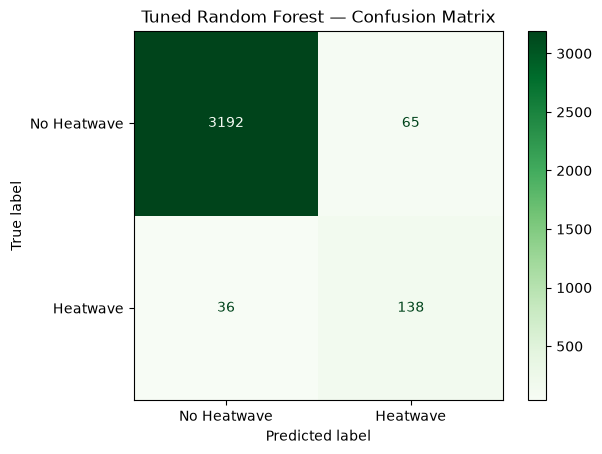

In [42]:
# evaluate best model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("TUNED RANDOM FOREST RESULTS")
print(classification_report(y_test, y_pred_best, target_names=["No Heatwave", "Heatwave"]))

cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=["No Heatwave", "Heatwave"]).plot(cmap="Greens")
plt.title("Tuned Random Forest — Confusion Matrix")
plt.show()

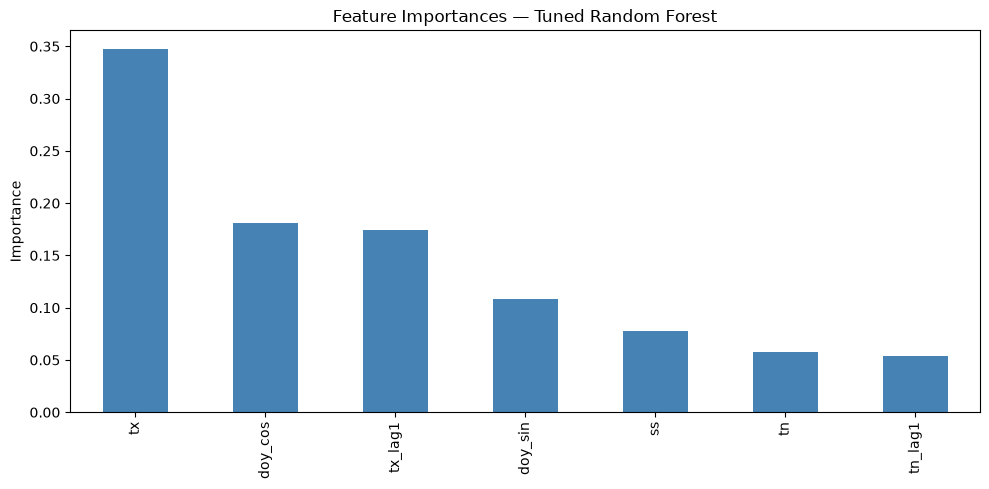

In [43]:
# feature importances
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)

importances.sort_values(ascending=False).plot.bar(
    figsize=(10, 5),
    color="steelblue",
    title="Feature Importances — Tuned Random Forest"
)
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# 5. MODEL COMPARISON

            Model  Precision  Recall    F1
              KNN      0.775   0.454 0.572
    Random Forest      0.833   0.517 0.638
RF + Oversampling      0.841   0.667 0.744
         RF Tuned      0.680   0.793 0.732


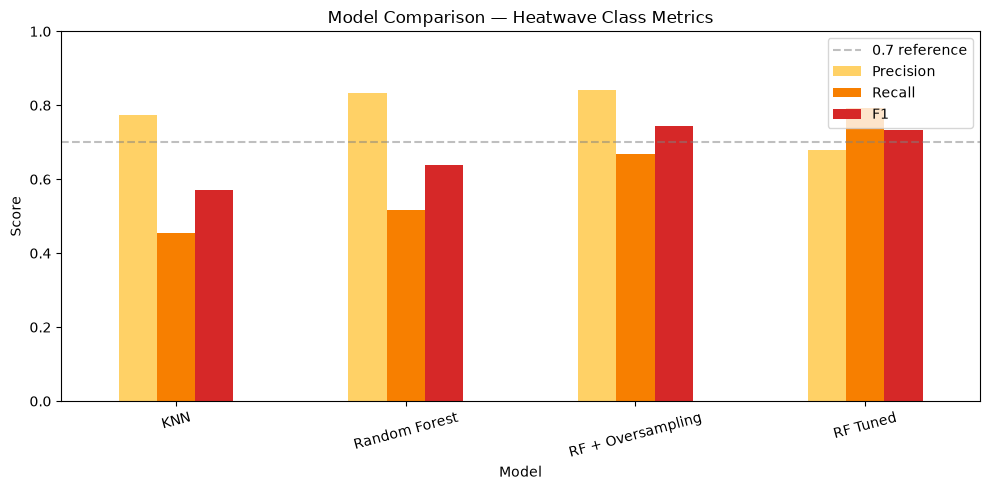

In [44]:
# final comparison table for all models
results = pd.DataFrame({
    "Model": ["KNN", "Random Forest", "RF + Oversampling", "RF Tuned"],
    "Precision": [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_balanced),
        precision_score(y_test, y_pred_best)
    ],
    "Recall": [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_best)
    ],
    "F1": [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_best)
    ]
}).round(3)

# Print table
print(results.to_string(index=False))

# Visualise it
results.set_index("Model")[["Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(10, 5),
    color=["#FFD166", "#F77F00", "#D62828"],
    ylim=(0, 1)
)
plt.title("Model Comparison — Heatwave Class Metrics")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.axhline(0.7, linestyle="--", color="gray", alpha=0.5, label="0.7 reference")
plt.legend()
plt.tight_layout()

plt.savefig(
    "heatwave_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)
plt.show()

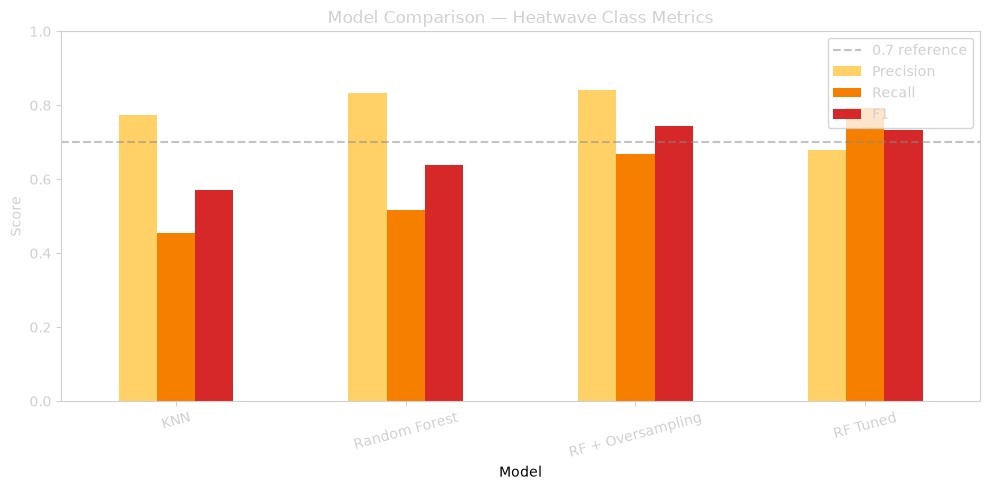

In [45]:
ax = results.set_index("Model")[["Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(10, 5),
    color=["#FFD166", "#F77F00", "#D62828"],
    ylim=(0, 1)
)

gray = "#D0D0D0"

# Transparent background
ax.set_facecolor("none")
plt.gcf().patch.set_alpha(0)

# Title and axis label
plt.title("Model Comparison — Heatwave Class Metrics", color=gray)
plt.ylabel("Score", color=gray)

# Tick labels
plt.xticks(rotation=15)
ax.tick_params(axis="x", colors=gray)
ax.tick_params(axis="y", colors=gray)

# Axis lines
for spine in ax.spines.values():
    spine.set_color(gray)

# Reference line
plt.axhline(
    0.7,
    linestyle="--",
    color="#888888",
    alpha=0.5,
    label="0.7 reference"
)

# Legend text
legend = plt.legend()
for text in legend.get_texts():
    text.set_color(gray)

plt.tight_layout()

plt.savefig(
    "heatwave_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

**CONCLUSIONS**:

- KNN (baseline):
Lowest performer across the board. Recall of 0.45 confirms it misses more than half of all real heatwave days. With only 7 features and a 5-neighbour vote, the rare heatwave class is consistently outvoted by its more common neighbours. Used mainly as a reference point to show how much the other models improve on it.

- Basic Random Forest:
A modest improvement over KNN (F1 0.572 → 0.643), but recall barely moved (0.454 → 0.523). Even with class_weight="balanced", the model is still cautious about predicting the minority class. Precision is high (0.835) — when it does call a heatwave, it's usually right — but it's still letting nearly half of real heatwaves slip through undetected.

- RF + Oversampling (best overall model):
This is the clear winner on F1 (0.744), and it makes sense why: oversampling exposes the trees to many more (duplicated) heatwave examples during training, so the model learns the heatwave pattern more thoroughly rather than relying on a reweighted loss function alone. Both precision (0.841) and recall (0.667) improved together, which is the ideal outcome.

- RF Tuned:
This is the most interesting result. GridSearchCV optimised purely for F1, and it found a configuration that pushes recall up to 0.793 which is the highest of any model at the cost of precision dropping to 0.680, the lowest of any model. This is a real trade-off: the tuned model is willing to accept more false alarms in exchange for catching more actual heatwaves. Its F1 (0.732) ends up just slightly below the oversampled model.



# 6. PREDICTING A HEATWAVE

In [46]:
import requests

In [47]:
# get recent PAST days (to build real lag features) + 7-day forecast 
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 51.4700,
    "longitude": -0.4543,
    "daily": "temperature_2m_max,temperature_2m_min,sunshine_duration",
    "timezone": "Europe/London",
    "past_days": 1,        # gets yesterday (June 17) as real lag data
    "forecast_days": 7
}

response = requests.get(url, params=params)
data = response.json()

full = pd.DataFrame({
    "date": pd.to_datetime(data["daily"]["time"]),
    "tx": data["daily"]["temperature_2m_max"],
    "tn": data["daily"]["temperature_2m_min"],
    "ss": [s / 3600 for s in data["daily"]["sunshine_duration"]]  # seconds → hours
})

print(full)

        date    tx    tn         ss
0 2026-06-18  24.0  16.9  12.000000
1 2026-06-19  28.2  16.4  15.599511
2 2026-06-20  25.1  17.3  10.317586
3 2026-06-21  29.5  18.8  15.425339
4 2026-06-22  31.1  19.7  14.843656
5 2026-06-23  32.3  20.7  15.902264
6 2026-06-24  32.2  25.2  15.779139
7 2026-06-25  29.8  19.4  15.865744


In [48]:
# calculate lag features 
full["tx_lag1"] = full["tx"].shift(1)
full["tn_lag1"] = full["tn"].shift(1)

forecast = full.iloc[1:].reset_index(drop=True)

print(forecast)

        date    tx    tn         ss  tx_lag1  tn_lag1
0 2026-06-19  28.2  16.4  15.599511     24.0     16.9
1 2026-06-20  25.1  17.3  10.317586     28.2     16.4
2 2026-06-21  29.5  18.8  15.425339     25.1     17.3
3 2026-06-22  31.1  19.7  14.843656     29.5     18.8
4 2026-06-23  32.3  20.7  15.902264     31.1     19.7
5 2026-06-24  32.2  25.2  15.779139     32.3     20.7
6 2026-06-25  29.8  19.4  15.865744     32.2     25.2


In [49]:
# create doy_sin and doy_cos features
forecast["doy"] = forecast["date"].dt.dayofyear
forecast["doy_sin"] = np.sin(2 * np.pi * forecast["doy"] / 365.25)
forecast["doy_cos"] = np.cos(2 * np.pi * forecast["doy"] / 365.25)

In [50]:
# predict whether there will be a heatwave at heathro3, london next week according to the RF+oversampling model
features = ["tx", "tx_lag1", "ss", "tn", "tn_lag1", "doy_sin", "doy_cos"]
X_forecast = forecast[features]

forecast["heatwave_predicted"] = rf_balanced.predict(X_forecast)
forecast["heatwave_probability"] = rf_balanced.predict_proba(X_forecast)[:, 1].round(3)

print(forecast[["date", "tx", "tn", "ss", "heatwave_predicted", "heatwave_probability"]])

        date    tx    tn         ss  heatwave_predicted  heatwave_probability
0 2026-06-19  28.2  16.4  15.599511                   0                  0.19
1 2026-06-20  25.1  17.3  10.317586                   0                  0.03
2 2026-06-21  29.5  18.8  15.425339                   0                  0.36
3 2026-06-22  31.1  19.7  14.843656                   0                  0.28
4 2026-06-23  32.3  20.7  15.902264                   0                  0.35
5 2026-06-24  32.2  25.2  15.779139                   0                  0.34
6 2026-06-25  29.8  19.4  15.865744                   0                  0.34


**RESULT:**
The model predicts no heatwave for the next 7 days. However the probability column is steadily climbing from 0.00 on June 18 up to 0.37 by June 24. That trend matters as the model isn't confidently saying "no heatwave" ,it's saying "not yet, but it's building."
If June 25th and 26th continue this trajectory (similarly hot, especially with tn staying above ~20°C), we'd likely cross into actual heatwave territory. This forecast is best read as "early warning, not yet confirmed".

In [51]:
# predict whether there will be a heatwave at heathrow, london next week according to the RF+oversampling model
features = ["tx", "tx_lag1", "ss", "tn", "tn_lag1", "doy_sin", "doy_cos"]
X_forecast = forecast[features]

forecast["heatwave_predicted_tuned"] = best_rf.predict(X_forecast)
forecast["heatwave_probability_tuned"] = best_rf.predict_proba(X_forecast)[:, 1].round(3)

print(forecast[["date", "tx", "tn", "ss", "heatwave_predicted_tuned", "heatwave_probability_tuned"]])

        date    tx    tn         ss  heatwave_predicted_tuned  \
0 2026-06-19  28.2  16.4  15.599511                         0   
1 2026-06-20  25.1  17.3  10.317586                         0   
2 2026-06-21  29.5  18.8  15.425339                         0   
3 2026-06-22  31.1  19.7  14.843656                         0   
4 2026-06-23  32.3  20.7  15.902264                         0   
5 2026-06-24  32.2  25.2  15.779139                         0   
6 2026-06-25  29.8  19.4  15.865744                         0   

   heatwave_probability_tuned  
0                       0.292  
1                       0.024  
2                       0.490  
3                       0.361  
4                       0.417  
5                       0.408  
6                       0.393  


Still no heatwave predicted across all 7 days, but the probabilities tell a more nuanced story than the RF + Oversampling run.